# Persistence
    For assistance in Langgraph refers to the ability to save and restored the state of a workflow over time.
    
    Persistence not only stores last state , but also all the interim states of a workflow too.
    
    Due to persistence are able to implement concepts like 
    
    - fault tolerance in langGraph
    - resume old chats
    - HITL
    - short term memory in bots
    - time travel 
    - debugging 


### workflow used here
    Here we are creating a simple workflow where we'll pass a topic and the llm will generate a joke on it
    And then the llm in other node will explain the joke

In [3]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , List , Annotated 
import operator 
from langchain_google_genai import ChatGoogleGenerativeAI 
from dotenv import load_dotenv 
from langchain_core.messages import BaseMessage , HumanMessage

from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [61]:
# creating the state for the workflow 
class JokeState(TypedDict):

    topic : str 
    joke : str 
    expla : str

In [10]:
def gen_joke(state:JokeState) -> JokeState:

    prompt = f"generate a short funny joke on topic {state["topic"]}"
    res = llm.invoke(prompt).content
    return {"joke":res}
    
def explain_joke(state:JokeState) -> JokeState:

    prompt = f"generate a small explanation of this joke : {state["joke"]} "
    res = llm.invoke(prompt).content
    return {"expla":res}

In [62]:
graph = StateGraph(JokeState)

# adding nodes
graph.add_node('gen_joke',gen_joke)
graph.add_node("explain_joke",explain_joke)

# creating edges 
graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","explain_joke")
graph.add_edge("explain_joke",END)

# InMemorySaver() implements the Persistence using the RAM till the program runs 
checkpointer = InMemorySaver() 

workflow = graph.compile(checkpointer = checkpointer)

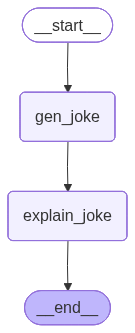

In [14]:
workflow

In [15]:
config1 = {"configurable":{"thread_id":"1"}} # thread_id is just to keep track of user 
    # like which user is communicating with the chatbot , it can be more than 1 at a time so each has his own
    # thread_id 
workflow.invoke({"topic":"fart"},config = config1)

{'topic': 'fart',
 'joke': "I just let out a silent fart in the elevator.\n\nNow everyone's looking at the dog.",
 'expla': 'This joke plays on a few key elements:\n\n1.  **The Silent Fart:** The "silent" aspect is crucial. If it had been audible, the source might be easier to pinpoint. Since it\'s silent, the only evidence is the smell.\n2.  **The Confined Space:** An elevator is a small, enclosed area where smells quickly become undeniable and inescapable.\n3.  **The Scapegoat:** When a bad smell appears in a confined space and the source isn\'t immediately obvious, people naturally look for a culprit. Dogs are known for passing gas, and they can\'t object or deny it, making them the perfect, innocent scapegoat.\n\nThe humor comes from the narrator successfully deceiving everyone and getting away with it, while the innocent dog takes all the blame and dirty looks. It\'s a classic situation of mischievous misdirection and relatable awkwardness.'}

In [19]:
data = [workflow.get_state(config = config1)] # used to get the final state data 
data[0]

StateSnapshot(values={'topic': 'fart', 'joke': "I just let out a silent fart in the elevator.\n\nNow everyone's looking at the dog.", 'expla': 'This joke plays on a few key elements:\n\n1.  **The Silent Fart:** The "silent" aspect is crucial. If it had been audible, the source might be easier to pinpoint. Since it\'s silent, the only evidence is the smell.\n2.  **The Confined Space:** An elevator is a small, enclosed area where smells quickly become undeniable and inescapable.\n3.  **The Scapegoat:** When a bad smell appears in a confined space and the source isn\'t immediately obvious, people naturally look for a culprit. Dogs are known for passing gas, and they can\'t object or deny it, making them the perfect, innocent scapegoat.\n\nThe humor comes from the narrator successfully deceiving everyone and getting away with it, while the innocent dog takes all the blame and dirty looks. It\'s a classic situation of mischievous misdirection and relatable awkwardness.'}, next=(), config={'

In [31]:
fulldata = list(workflow.get_state_history(config1)) # used to get all data interim and final of workflow 
fulldata

[StateSnapshot(values={'topic': 'fart', 'joke': "I just let out a silent fart in the elevator.\n\nNow everyone's looking at the dog.", 'expla': 'This joke plays on a few key elements:\n\n1.  **The Silent Fart:** The "silent" aspect is crucial. If it had been audible, the source might be easier to pinpoint. Since it\'s silent, the only evidence is the smell.\n2.  **The Confined Space:** An elevator is a small, enclosed area where smells quickly become undeniable and inescapable.\n3.  **The Scapegoat:** When a bad smell appears in a confined space and the source isn\'t immediately obvious, people naturally look for a culprit. Dogs are known for passing gas, and they can\'t object or deny it, making them the perfect, innocent scapegoat.\n\nThe humor comes from the narrator successfully deceiving everyone and getting away with it, while the innocent dog takes all the blame and dirty looks. It\'s a classic situation of mischievous misdirection and relatable awkwardness.'}, next=(), config={

In [30]:
len(fulldata) # 4 checkpoints 

4

# 1. time travel 

    We can even start the execution from a certain node , this feature is used for complex workflows
    Where there are many notes and we debug any problem using this time, travel feature by moving to
    Any previous note and re-executing all the notes after that

    This is done by passing the checkpoint ID of the previous node from which we want to start the execution which is given get_state_history function

In [42]:
fulldata[-1] # start node where we gave the joke topic 
# we will copy its checkpoint_id:"1f11641a-b25e-66d0-bfff-61ba704f0f0c"

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11641a-b25e-66d0-bfff-61ba704f0f0c'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-03-02T14:11:12.526901+00:00', parent_config=None, tasks=(PregelTask(id='a24f039b-607a-6014-9ffd-b66c9e36b8be', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'fart'}),), interrupts=())

In [43]:
#now we can re-simulate its working from this node 
workflow.invoke(None,
                config={"configurable":
                        {"thread_id":"1","checkpoint_id":"1f11641a-b25e-66d0-bfff-61ba704f0f0c"}})


{'topic': 'fart',
 'joke': 'Why did the fart get kicked out of the library?\n\nBecause it was a silent but deadly weapon!',
 'expla': 'This joke is a play on the common phrase "silent but deadly," which is often used to describe a fart that doesn\'t make a sound but has a very strong, unpleasant odor.\n\nHere\'s the breakdown:\n\n1.  **"Silent"**: Libraries are places that require quiet. A "silent" fart would technically adhere to the sound rules.\n2.  **"But deadly weapon"**: The "deadly" refers to the powerful and offensive smell of the fart, which would certainly cause a disturbance and be unwelcome in any quiet, enclosed space like a library, effectively "kicking it out" (or at least making everyone else leave!).\n\nThe humor comes from applying the literal "silent" aspect to the library\'s rules, then using the metaphorical "deadly" aspect to explain why it would still be a problem.'}

# 2. updating the state

    We can also update the state by changing the value of the node at any point in the workflow and then
    Re-execute all the notes below it with that new value

In [56]:
# example : in the workflow, instead of fart, I will pass the value as samosa

workflow.update_state(config={"configurable":
                                 {"thread_id":"1",
                                  "checkpoint_id":"1f11641a-b25e-66d0-bfff-61ba704f0f0c",
                                  "checkpoint_ns":""}} , 
                      values = {"topic":"samosa"})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f116482-695e-6fee-8000-c7a763f3b63e'}}

In [59]:
list(workflow.get_state_history(config=config1))[0]

StateSnapshot(values={'topic': 'samosa'}, next=('gen_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f116482-695e-6fee-8000-c7a763f3b63e'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-03-02T14:57:36.601259+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11641a-b25e-66d0-bfff-61ba704f0f0c'}}, tasks=(PregelTask(id='07b37754-44dc-071d-18f8-bcfefaf6450d', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [60]:
# we can see the topic name is samosa here , now we can run from this checkpoint by passing its id 
workflow.invoke(None,config = {'configurable': 
                               {'thread_id': '1', 
                                'checkpoint_ns': '', 
                                'checkpoint_id': '1f116482-695e-6fee-8000-c7a763f3b63e'}})

{'topic': 'samosa',
 'joke': 'Why did the samosa get invited to all the parties?\n\nBecause it had a lot of *filling* personality!',
 'expla': 'This joke is a pun that plays on the word "filling."\n\n1.  **Literal Meaning (Samosa):** A samosa is a pastry that is literally **filled** with ingredients like potatoes, peas, and spices.\n2.  **Figurative Meaning (Personality):** When someone has a "filling personality," it sounds like "full-ing personality" or "full personality." This implies they are vibrant, interesting, engaging, and bring a lot of energy and substance to social situations – they "fill" the room with their presence.\n\nThe humor comes from cleverly using the literal characteristic of a samosa (its delicious contents) to describe a desirable human trait (a rich and engaging personality) through wordplay.'}

# 3. short term memory to bot 

### workflow used here 

    We are creating a simple chatbot, what which takes in the user query and generate a response through LLM

In [63]:
from langgraph.graph.message import add_messages 

class ChatState(TypedDict): 
    # BaseMessage has all three system , human , and tool messages  
    # so the messages var can store all 3 types of messages
    messages : Annotated[list[BaseMessage] , add_messages] 
    # add_messages does the same thing as operator.add
    # but it is more optimised to work with BaseMessage class of langgraph 


In [64]:
def chat(state : ChatState)  -> ChatState:

    # usr query 
    messages = state["messages"]
    # askk llm 
    response = llm.invoke(messages)
    # return the response 
    return {"messages":[response]}
    

In [65]:
graph = StateGraph(ChatState)

graph.add_node("chatllm_node",chat)

graph.add_edge(START,"chatllm_node")
graph.add_edge("chatllm_node",END)

chatbot = graph.compile()

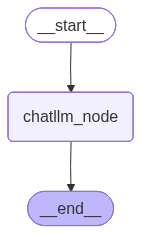

In [66]:
chatbot

In [67]:
init_state = {"messages":[HumanMessage(content="what is capital of india")]}
chatbot.invoke(init_state)

{'messages': [HumanMessage(content='what is capital of india', additional_kwargs={}, response_metadata={}, id='050b67dc-102f-4aba-aba4-8a25d01ab6bf'),
  AIMessage(content='The capital of India is **New Delhi**.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019caf1a-cd2a-7421-b784-130634648c8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 31, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 22}})]}

In [68]:
#continous chat 

while True:

    usr_message = input("you ->  ")

    if usr_message.strip().lower()  in ["exit","stop","bye","quit"]:
        break 

    response = chatbot.invoke({"messages":[HumanMessage(content=usr_message)]})
    print("walter -> " , response["messages"][-1].content)

you ->   my name is sehaj 


walter ->  Hi Sehaj! It's nice to meet you.


you ->   what is my name ?


walter ->  I'm sorry, but as an AI, I don't have access to personal information about you, including your name. I don't retain memory of individual users across conversations.

If you'd like me to call you something during our chat, feel free to tell me!


you ->   exit 


In [70]:
"""
It’s happening because we are invoking the chatbot inside the loop every single time, and with each new invoke,
a completely fresh state is being created.

So even if you provide your name in one message, on the next iteration:
	•	The previous messages are not carried forward
	•	The earlier state gets discarded
	•	A brand-new state is passed to the model

This occurs because we have connected the ChatLLM node directly to END.
When the graph execution reaches END, the workflow terminates — and the state does not persist beyond that execution cycle.

"""

'\nIt’s happening because we are invoking the chatbot inside the loop every single time, and with each new invoke,\na completely fresh state is being created.\n\nSo even if you provide your name in one message, on the next iteration:\n\t•\tThe previous messages are not carried forward\n\t•\tThe earlier state gets discarded\n\t•\tA brand-new state is passed to the model\n\nThis occurs because we have connected the ChatLLM node directly to END.\nWhen the graph execution reaches END, the workflow terminates — and the state does not persist beyond that execution cycle.\n\n'

In [71]:
"""
so we will use the concept of persistace here 
it will save all the data from state when the excution ends 

    types of persistance : 
        - RAM  - It saves data in RAM until the program isnt terminated
        - database 

we will be using RAM based for now 
"""

from langgraph.checkpoint.memory import MemorySaver

checkpoint = MemorySaver() # create a object of memory saver class 

graph = StateGraph(ChatState)
graph.add_node("chatllm_node",chat)
graph.add_edge(START,"chatllm_node")
graph.add_edge("chatllm_node",END)

chatbot = graph.compile(checkpointer = checkpoint) # pass it to checkpointer parameter while compilation


In [72]:
while True:
    thread_id = "1"
    
    usr_message = input("you ->  ")
    
    config = {"configurable":{"thread_id":thread_id}} # thread_id is just to keep track of user 
    # like which user is communicating with the chatbot , it can be more than 1 at a time so each has his own
    # thread_id 
    
    if usr_message.strip().lower()  in ["exit","stop","bye","quit"]:
        break 

    response = chatbot.invoke({"messages":[HumanMessage(content=usr_message)]},config = config)
    print("walter -> " , response["messages"][-1].content)

you ->   my name is sehaj 


walter ->  It's nice to meet you, Sehaj!


you ->   who are u 


walter ->  I am a large language model, trained by Google.


you ->   what is my name ?


walter ->  Your name is Sehaj.


you ->   exit 
